In [1]:
import pyspark

VBox()

Starting Spark application


ID,YARN Application ID,Kind,State,Spark UI,Driver log,User,Current session?
7,application_1764218763672_0008,pyspark,idle,Link,Link,None,✔


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

SparkSession available as 'spark'.


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [2]:
from pyspark.sql import SparkSession

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [3]:
cores = spark._jsc.sc().getExecutorMemoryStatus().keySet().size()
appid = spark._jsc.sc().applicationId()
print("You are working with", cores, "core(s) on appid: ", appid)
spark

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

You are working with 5 core(s) on appid:  application_1764218763672_0008

In [4]:
from pyspark.sql import functions as F

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [5]:
path = "s3://csc555-mulchrone-final/data/"

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [6]:
# read in the data
df = spark.read.csv(path+'Synthetic_Financial_datasets_log.csv',inferSchema=True,header=True)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [7]:
df.show(5)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|step|    type|  amount|   nameOrig|oldbalanceOrg|newbalanceOrig|   nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|   1| PAYMENT| 9839.64|C1231006815|     170136.0|     160296.36|M1979787155|           0.0|           0.0|      0|             0|
|   1| PAYMENT| 1864.28|C1666544295|      21249.0|      19384.72|M2044282225|           0.0|           0.0|      0|             0|
|   1|TRANSFER|   181.0|C1305486145|        181.0|           0.0| C553264065|           0.0|           0.0|      1|             0|
|   1|CASH_OUT|   181.0| C840083671|        181.0|           0.0|  C38997010|       21182.0|           0.0|      1|             0|
|   1| PAYMENT|11668.14|C2048537720|      41554.0|      29885.86|M1230701703|      

In [8]:
df.dtypes

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

[('step', 'int'), ('type', 'string'), ('amount', 'double'), ('nameOrig', 'string'), ('oldbalanceOrg', 'double'), ('newbalanceOrig', 'double'), ('nameDest', 'string'), ('oldbalanceDest', 'double'), ('newbalanceDest', 'double'), ('isFraud', 'int'), ('isFlaggedFraud', 'int')]

In [9]:
df.count()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

6362620

Repartition data on isFraud for efficient use of distributed system.

In [10]:
df_partition = df.repartition(20,"isFraud")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Calculate how much percent of the original balance and destination balance is the amount being transferred.

In [11]:
df_partition = df_partition.withColumn(
    "percentOrg", 
    F.when(F.col("oldbalanceOrg") != 0, F.col("amount") / F.col("oldbalanceOrg"))
     .otherwise(0.0)
).withColumn(
    "percentDest", 
    F.when(F.col("oldbalanceDest") != 0, F.col("amount") / F.col("oldbalanceDest"))
     .otherwise(0.0)
)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [12]:
df_partition.show(5)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+----+--------+---------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+----------+------------------+
|step|    type|   amount|   nameOrig|oldbalanceOrg|newbalanceOrig|   nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|percentOrg|       percentDest|
+----+--------+---------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+----------+------------------+
|  40|TRANSFER|  7887.75|C1551140519|      7887.75|           0.0| C311151183|           0.0|           0.0|      1|             0|       1.0|               0.0|
|  40|CASH_OUT|  7887.75| C418271713|      7887.75|           0.0| C795853330|           0.0|       7887.75|      1|             0|       1.0|               0.0|
|  40|TRANSFER| 31930.24|C1311186566|     31930.24|           0.0|C1907577066|           0.0|           0.0|      1|             0|       1.0|               0.0|
|  40|CASH_OUT| 31930.24|C12

Transform "type" column to dummy variables.

In [13]:
from pyspark.sql.functions import when

type_values = df_partition.select("type").distinct().rdd.flatMap(lambda x: x).collect()

for type_val in type_values:
    df_partition = df_partition.withColumn(f'type_{type_val}', 
                       when(F.col('type') == type_val, 1).otherwise(0))

df_partition = df_partition.drop('type')
df_partition.show(5)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+----+-------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+----------+--------------------+-------------+------------+------------+----------+-------------+
|step| amount|   nameOrig|oldbalanceOrg|newbalanceOrig|   nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|percentOrg|         percentDest|type_CASH_OUT|type_CASH_IN|type_PAYMENT|type_DEBIT|type_TRANSFER|
+----+-------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+----------+--------------------+-------------+------------+------------+----------+-------------+
|   1|  181.0|C1305486145|        181.0|           0.0| C553264065|           0.0|           0.0|      1|             0|       1.0|                 0.0|            0|           0|           0|         0|            1|
|   1|  181.0| C840083671|        181.0|           0.0|  C38997010|       21182.0|           0.0|      1|             0|       1

Get distribution of frauds in the data.

In [14]:
total_count = df_partition.count()

fraud_stats = df_partition.groupby("isFraud") \
    .agg(F.count("*").alias("count")) \
    .withColumn("percentage", F.round((F.col("count") / total_count) * 100, 2)) \
    .orderBy("isFraud")

fraud_stats.show()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+-------+-------+----------+
|isFraud|  count|percentage|
+-------+-------+----------+
|      0|6354407|     99.87|
|      1|   8213|      0.13|
+-------+-------+----------+

In [15]:
fraud_pct = fraud_stats.select("percentage").rdd.flatMap(lambda x: x).collect()[1]
fraud_pct

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

0.13

In [16]:
processed_path = path+'processed/'
processed_path

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

's3://csc555-mulchrone-final/data/processed/'

Transform the data into a format that Athena can read.

In [17]:
df_partition.write \
    .mode("overwrite") \
    .option("compression", "snappy") \
    .parquet(processed_path)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [18]:
df2 = spark.read.parquet(processed_path)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [19]:
df2.show(5)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+----+----------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+-------------------+------------------+-------------+------------+------------+----------+-------------+
|step|    amount|   nameOrig|oldbalanceOrg|newbalanceOrig|   nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|         percentOrg|       percentDest|type_CASH_OUT|type_CASH_IN|type_PAYMENT|type_DEBIT|type_TRANSFER|
+----+----------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+-------------------+------------------+-------------+------------+------------+----------+-------------+
|  18|  12756.09|C1715701002|    171830.01|     159073.92| M752830443|           0.0|           0.0|      0|             0|0.07423668310326001|               0.0|            0|           0|           1|         0|            0|
|  18|   8780.95|C1811023780|    159073.92|     150292.97|M1404577539|           0.0|   

In [5]:
# Athena configuration
DATABASE_NAME = 'default'
TABLE_NAME = 'financial-logs'
# AWS configuration (no need to specify credentials)
AWS_REGION = 'us-east-1'  # Replace with your AWS region
S3_BUCKET_NAME = 'csc555-mulchrone-final' # Change to your bucket name

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [6]:
import boto3

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [ ]:
# Initialize Athena client (no need to specify credentials)

athena_client = boto3.client('athena',
    aws_access_key_id='', #your access key
    aws_secret_access_key='', #your secret access key
    aws_session_token='', #your session token
    region_name = AWS_REGION) # should be us-east-1 in most cases.

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [23]:
create_table_query = f"""
CREATE EXTERNAL TABLE IF NOT EXISTS `{DATABASE_NAME}`.`{TABLE_NAME}` (
    step INT,
    type_CASH_OUT INT,
    type_CASH_IN INT,
    type_PAYMENT INT,
    type_DEBIT INT,
    type_TRANSFER INT,
    amount DOUBLE,
    nameOrig STRING,
    oldbalanceOrg DOUBLE,
    newbalanceOrig DOUBLE,
    nameDest STRING,
    oldbalanceDest DOUBLE,
    newbalanceDest DOUBLE,
    isFraud INT,
    isFlaggedFraud INT,
    percentOrg DOUBLE,
    percentDest DOUBLE
)
STORED AS PARQUET
LOCATION '{processed_path}'
"""
print(create_table_query.strip())

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

CREATE EXTERNAL TABLE IF NOT EXISTS `default`.`financial-logs` (
    step INT,
    type_CASH_OUT INT,
    type_CASH_IN INT,
    type_PAYMENT INT,
    type_DEBIT INT,
    type_TRANSFER INT,
    amount DOUBLE,
    nameOrig STRING,
    oldbalanceOrg DOUBLE,
    newbalanceOrig DOUBLE,
    nameDest STRING,
    oldbalanceDest DOUBLE,
    newbalanceDest DOUBLE,
    isFraud INT,
    isFlaggedFraud INT,
    percentOrg DOUBLE,
    percentDest DOUBLE
)
STORED AS PARQUET
LOCATION 's3://csc555-mulchrone-final/data/processed/'

In [24]:
response = athena_client.start_query_execution(
    QueryString=create_table_query.strip(),
    QueryExecutionContext={'Database': DATABASE_NAME},
    ResultConfiguration={'OutputLocation': f's3://{S3_BUCKET_NAME}/query_results/'}
)

print("Athena table creation query submitted.")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Athena table creation query submitted.

In [8]:
sc.install_pypi_package("numpy")
sc.install_pypi_package("pandas")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…


  Attempting uninstall: python-dateutil
    Found existing installation: python-dateutil 2.8.1
    Not uninstalling python-dateutil at /usr/lib/python3.9/site-packages, outside environment /mnt/yarn/usercache/livy/appcache/application_1764218763672_0008/container_1764218763672_0008_01_000003/tmp/spark-ca5465e0-5e26-434c-a1cd-bf9a8b6b79ff
    Can't uninstall 'python-dateutil'. No files were found to uninstall.

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas 2.3.2 requires tzdata>=2022.7, which is not installed.
matplotlib 3.9.4 requires contourpy>=1.0.1, which is not installed.
matplotlib 3.9.4 requires cycler>=0.10, which is not installed.
matplotlib 3.9.4 requires fonttools>=4.22.0, which is not installed.
matplotlib 3.9.4 requires importlib-resources>=3.2.0; python_version < "3.10", which is not installed.
matplotlib 3.9.4 requires kiwisolver>=1.3.1,

In [9]:
import numpy as np
import pandas as pd

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [10]:
import time

# Function to run Athena query
def run_athena_query(query, database, output_location):
    response = athena_client.start_query_execution(
        QueryString=query,
        QueryExecutionContext={
            'Database': database
        },
        ResultConfiguration={
            'OutputLocation': output_location
        }
    )
    return response['QueryExecutionId']

# Function to check query status
def check_query_status(query_execution_id):
    while True:
        response = athena_client.get_query_execution(QueryExecutionId=query_execution_id)
        status = response['QueryExecution']['Status']['State']
        if status == 'SUCCEEDED':
            print("Query succeeded!")
            break
        elif status in ['FAILED', 'CANCELLED']:
            print(f"Query {status.lower()}.")
            raise Exception(f"Query failed or was cancelled: {response}")
        time.sleep(2)

# Function to get query results and convert to pandas DataFrame
def get_query_results_as_dataframe(query_execution_id):
    # Fetching the query results
    results_paginator = athena_client.get_paginator('get_query_results')
    results_iter = results_paginator.paginate(QueryExecutionId=query_execution_id)

    # Initialize a list to store rows and columns for DataFrame
    columns = []
    rows = []

    # Process the result pages
    for results_page in results_iter:
        # Get column info from the first page
        if not columns:
            columns = [col['Label'] for col in results_page['ResultSet']['ResultSetMetadata']['ColumnInfo']]

        # Skip the first row of the first page (column headers)
        for row in results_page['ResultSet']['Rows'][1:]:
            rows.append([col.get('VarCharValue', None) for col in row['Data']])

    # Create DataFrame from the results
    df = pd.DataFrame(rows, columns=columns)
    return df

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Values to sample data for testing.

In [11]:
fraud1 = 8213
fraud0 = 6354407
fraud1_sample = int(fraud1 * .1)
fraud0_sample = int(fraud0 * .1)
fraud0_test = int(fraud0 * .3)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Query fraud and non-fraud data. For the scope of this project, the amount of non-fraud data will be reduced.

In [12]:
# query_sample = f'SELECT * FROM "default"."{TABLE_NAME}" WHERE isFraud = 1 limit {fraud1_sample};'
query = f'SELECT * FROM "default"."{TABLE_NAME}" WHERE isFraud = 1;'
database = 'default'
output_location = f's3://{S3_BUCKET_NAME}/query_results/'  # Change to your S3 bucket

# Run the query
query_execution_id = run_athena_query(query, database, output_location)

# Check the status of the query
check_query_status(query_execution_id)

# Fetch the results as a pandas DataFrame
df_sample1 = get_query_results_as_dataframe(query_execution_id)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Query succeeded!

In [13]:
# query_sample = f'SELECT * FROM "default"."{TABLE_NAME}" WHERE isFraud = 0 limit {fraud0_sample};'
query = f'SELECT * FROM "default"."{TABLE_NAME}" WHERE isFraud = 0 limit {fraud0_test};'
database = 'default'
output_location = f's3://{S3_BUCKET_NAME}/query_results/'  # Change to your S3 bucket

# Run the query
query_execution_id = run_athena_query(query, database, output_location)

# Check the status of the query
check_query_status(query_execution_id)

# Fetch the results as a pandas DataFrame
df_sample0 = get_query_results_as_dataframe(query_execution_id)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Query succeeded!

Identify columns we will use in the model.

In [14]:
drop_cols = ['step','nameorig','namedest','isflaggedfraud']
cols = list(df_sample0.columns)
filter_cols = list(set(cols) - set(drop_cols))
filter_cols

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

['type_transfer', 'percentdest', 'type_cash_out', 'type_cash_in', 'type_payment', 'amount', 'oldbalanceorg', 'isfraud', 'type_debit', 'oldbalancedest', 'percentorg', 'newbalancedest', 'newbalanceorig']

In [15]:
df_spark1 = spark.createDataFrame(df_sample1[filter_cols])
df_spark0 = spark.createDataFrame(df_sample0[filter_cols])

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Transform schema of both dataframes.

In [16]:
from pyspark.sql.functions import col

df_spark1 = df_spark1.withColumn('isfraud', col("isfraud").cast("int"))
df_spark1 = df_spark1.withColumn('type_cash_in', col("type_cash_in").cast("int"))
df_spark1 = df_spark1.withColumn('type_cash_out', col("type_cash_out").cast("int"))
df_spark1 = df_spark1.withColumn('type_payment', col("type_payment").cast("int"))
df_spark1 = df_spark1.withColumn('type_debit', col("type_debit").cast("int"))
df_spark1 = df_spark1.withColumn('type_transfer', col("type_transfer").cast("int"))
df_spark1 = df_spark1.withColumn('amount', col("amount").cast("float"))
df_spark1 = df_spark1.withColumn('oldbalanceorg', col("oldbalanceorg").cast("float"))
df_spark1 = df_spark1.withColumn('newbalanceorig', col("newbalanceorig").cast("float"))
df_spark1 = df_spark1.withColumn('oldbalancedest', col("oldbalancedest").cast("float"))
df_spark1 = df_spark1.withColumn('newbalancedest', col("newbalancedest").cast("float"))
df_spark1 = df_spark1.withColumn('percentorg', col("percentorg").cast("float"))
df_spark1 = df_spark1.withColumn('percentdest', col("percentdest").cast("float"))
df_spark1 = df_spark1.withColumnRenamed('isfraud', 'label')

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [17]:
df_spark0 = df_spark0.withColumn('isfraud', col("isfraud").cast("int"))
df_spark0 = df_spark0.withColumn('type_cash_in', col("type_cash_in").cast("int"))
df_spark0 = df_spark0.withColumn('type_cash_out', col("type_cash_out").cast("int"))
df_spark0 = df_spark0.withColumn('type_payment', col("type_payment").cast("int"))
df_spark0 = df_spark0.withColumn('type_debit', col("type_debit").cast("int"))
df_spark0 = df_spark0.withColumn('type_transfer', col("type_transfer").cast("int"))
df_spark0 = df_spark0.withColumn('amount', col("amount").cast("float"))
df_spark0 = df_spark0.withColumn('oldbalanceorg', col("oldbalanceorg").cast("float"))
df_spark0 = df_spark0.withColumn('newbalanceorig', col("newbalanceorig").cast("float"))
df_spark0 = df_spark0.withColumn('oldbalancedest', col("oldbalancedest").cast("float"))
df_spark0 = df_spark0.withColumn('newbalancedest', col("newbalancedest").cast("float"))
df_spark0 = df_spark0.withColumn('percentorg', col("percentorg").cast("float"))
df_spark0 = df_spark0.withColumn('percentdest', col("percentdest").cast("float"))
df_spark0 = df_spark0.withColumnRenamed('isfraud', 'label')

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Split data from both fraud and valid data to maintain class balance for modeling and validation.

In [18]:
rand_st = 64327
split0, val0 = df_spark0.randomSplit([0.9, 0.1], seed=rand_st)
split1, val1 = df_spark1.randomSplit([0.9, 0.1], seed=rand_st)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [19]:
split_data = split0.union(split1)
val = val0.union(val1)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [20]:
cols = list(split_data.columns)
cols.remove('label')
cols

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

['type_transfer', 'percentdest', 'type_cash_out', 'type_cash_in', 'type_payment', 'amount', 'oldbalanceorg', 'type_debit', 'oldbalancedest', 'percentorg', 'newbalancedest', 'newbalanceorig']

In [21]:
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.types import * 
from pyspark.sql.functions import *

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Create vector assemblers from model data and validation data.

In [22]:
assembler = VectorAssembler(inputCols=cols,outputCol='features')

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [23]:
val_data = assembler.transform(val).select('label','features')

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [24]:
cv_data = assembler.transform(split_data).select('label','features')

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

## Build classification model

In [25]:
sc.install_pypi_package("scikit-learn")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [26]:
from pyspark.ml.classification import *
from pyspark.ml.evaluation import *
from pyspark.sql.functions import *
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [27]:
sc.install_pypi_package("python-dateutil==2.8.2")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

  Attempting uninstall: python-dateutil
    Found existing installation: python-dateutil 2.9.0.post0
    Uninstalling python-dateutil-2.9.0.post0:
      Successfully uninstalled python-dateutil-2.9.0.post0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
matplotlib 3.9.4 requires contourpy>=1.0.1, which is not installed.
matplotlib 3.9.4 requires cycler>=0.10, which is not installed.
matplotlib 3.9.4 requires fonttools>=4.22.0, which is not installed.
matplotlib 3.9.4 requires importlib-resources>=3.2.0; python_version < "3.10", which is not installed.
matplotlib 3.9.4 requires kiwisolver>=1.3.1, which is not installed.
matplotlib 3.9.4 requires pillow>=8, which is not installed.

In [28]:
sc.install_pypi_package("matplotlib")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Recall will be primary evaluator to ensure maximum amount of frauds are caught. F1 will also evaluate model performance.

In [29]:
recall_evaluator = MulticlassClassificationEvaluator(metricName='weightedRecall')
f1_evaluator = MulticlassClassificationEvaluator(metricName="f1")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Logistic Regression Clasification function to test multiple thresholds of prediction confidence thresholds.

In [30]:
def logregcv(data, validate, evaluate, t):
    classifier = LogisticRegression(threshold=t)

    # Then Set up your parameter grid for the cross validator to conduct hyperparameter tuning
    paramGrid = (ParamGridBuilder().addGrid(classifier.maxIter, [10,15,20]).build())

    # Then set up the Cross Validator which requires all of the following parameters:
    crossval = CrossValidator(estimator=classifier,
                              estimatorParamMaps=paramGrid,
                              evaluator=evaluate,
                              numFolds=5) # 3 + is best practice

    # Then fit your model
    fitModel = crossval.fit(data)

    # Collect the best model and
    # print the coefficient matrix
    # These values should be compared relative to eachother
    # And intercepts can be prepared to other models
    BestModel = fitModel.bestModel
    print("Intercept: " + str(BestModel.interceptVector))
    print("Coefficients: \n" + str(BestModel.coefficientMatrix))

    # You can extract the best model from this run like this if you want
    LR_BestModel = BestModel
    # print(LR_BestModel.params)

    # Next you need to generate predictions on the test dataset
    # fitModel automatically uses the best model 
    # so we don't need to use BestModel here
    predictions = fitModel.transform(validate)

    # Now print the accuracy rate of the model or AUC for a binary classifier
    recall = (recall_evaluator.evaluate(predictions))
    f1 = (f1_evaluator.evaluate(predictions))
    print("Recall: ", recall)
    print("F1: ", f1)
    print("maxIter:", BestModel.getMaxIter())
    print("threshold:", BestModel.getThreshold())
    
    return predictions

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Function to display confusion matrix from model classification results.

In [31]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplot plt

# plt.clf()
# plt.close('all')

def fraud_confusion_matrix(predictions, colors, t):
#     plt.clf()
    predictions_pd = predictions.select('label', 'prediction').toPandas()

    # Create confusion matrix
    cm = confusion_matrix(predictions_pd['label'], predictions_pd['prediction'])

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap=colors)

    # Add colorbar
    plt.colorbar(im, ax=ax)

    # Set ticks and labels
    ax.set_xticks(np.arange(2))
    ax.set_yticks(np.arange(2))
    ax.set_xticklabels(['Valid', 'Fraud'])
    ax.set_yticklabels(['Valid', 'Fraud'])

    # Add text annotations
    for i in range(2):
        for j in range(2):
            text = ax.text(j, i, cm[i, j],
                          ha="center", va="center", color="black", fontsize=20)
    
    pct = t*100
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix {pct}% Confidence')
    plt.tight_layout()
    plt.show()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Evaluate fraud predictions model with 5% confidence.

In [32]:
predictions05 = logregcv(cv_data, val_data, recall_evaluator, t=0.05)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Intercept: [-33.503811166090415]
Coefficients: 
DenseMatrix([[ 3.00125080e+01,  1.58203059e-05,  2.85613224e+01,
              -2.70133120e+01, -1.82556753e+01,  6.51934519e-07,
               1.02096668e-05, -1.19680479e+01,  1.36104398e-06,
              -3.18949304e-03, -3.25034117e-06, -8.71144899e-06]])
Recall:  0.9947596012899442
F1:  0.995310255303995
maxIter: 15
threshold: 0.05

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

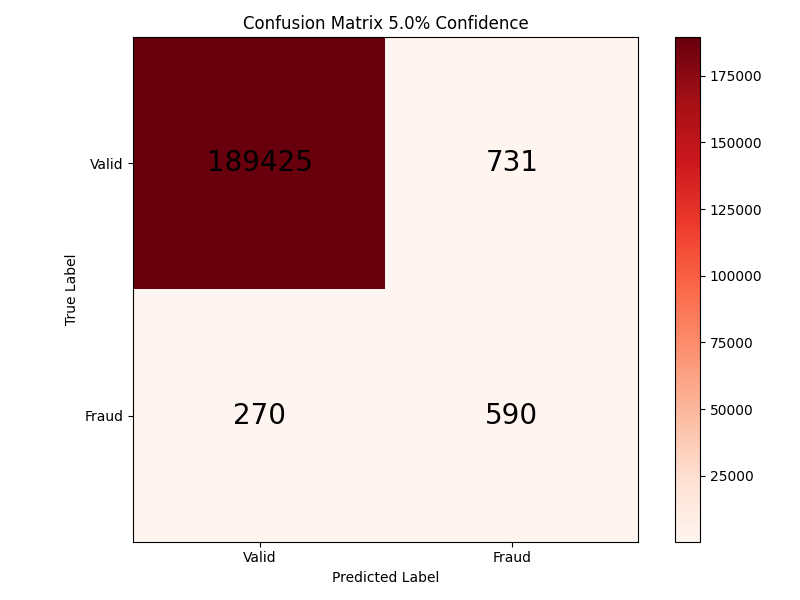

In [34]:
fraud_confusion_matrix(predictions05,'Reds',0.05)
%matplot plt

Evaluate fraud predictions model with 1% confidence.

In [35]:
predictions01 = logregcv(cv_data, val_data, recall_evaluator, t=0.01)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Intercept: [-33.503811166090905]
Coefficients: 
DenseMatrix([[ 3.00125080e+01,  1.58203059e-05,  2.85613224e+01,
              -2.70133120e+01, -1.82556753e+01,  6.51934519e-07,
               1.02096668e-05, -1.19680479e+01,  1.36104398e-06,
              -3.18949304e-03, -3.25034117e-06, -8.71144899e-06]])
Recall:  0.9607519788918206
F1:  0.9762247429157659
maxIter: 15
threshold: 0.01

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

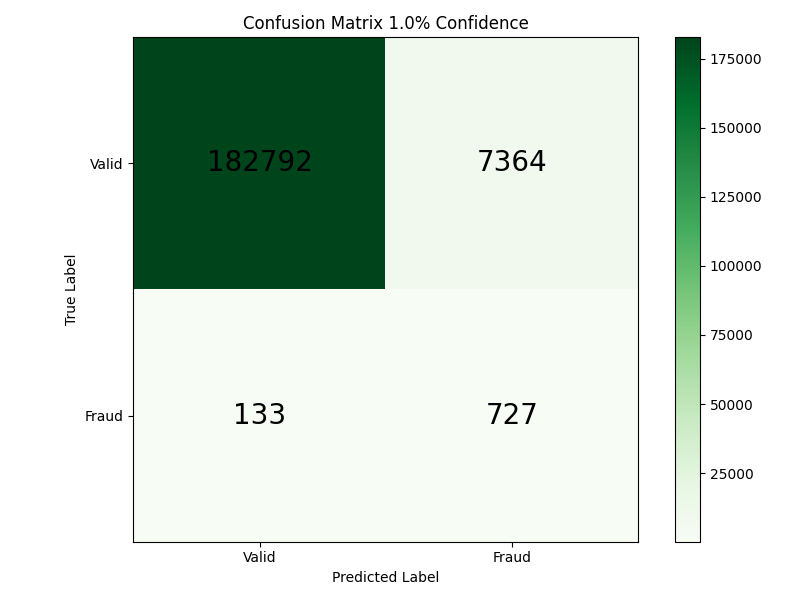

In [36]:
fraud_confusion_matrix(predictions01,'Greens', 0.01)
%matplot plt

Evaluate fraud predictions model with 0.1% confidence.

In [37]:
predictions001 = logregcv(cv_data, val_data, recall_evaluator, t=0.001)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Intercept: [-33.50381116609141]
Coefficients: 
DenseMatrix([[ 3.00125080e+01,  1.58203059e-05,  2.85613224e+01,
              -2.70133120e+01, -1.82556753e+01,  6.51934519e-07,
               1.02096668e-05, -1.19680479e+01,  1.36104398e-06,
              -3.18949304e-03, -3.25034117e-06, -8.71144899e-06]])
Recall:  0.7523139422875571
F1:  0.8542454995306215
maxIter: 15
threshold: 0.001

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

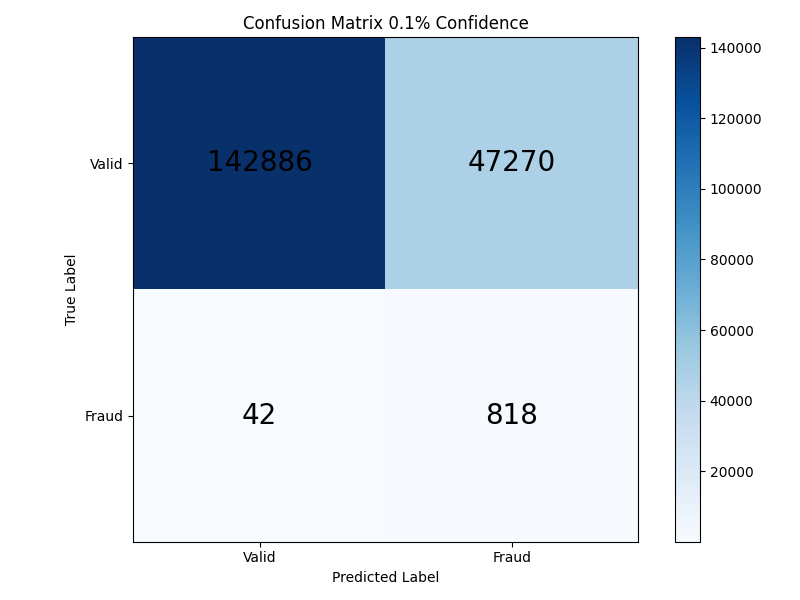

In [38]:
fraud_confusion_matrix(predictions001,'Blues', 0.001)
%matplot plt

In [39]:
predictions0001 = logregcv(cv_data, val_data, recall_evaluator, t=0.0001)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Intercept: [-33.50381116609089]
Coefficients: 
DenseMatrix([[ 3.00125080e+01,  1.58203059e-05,  2.85613224e+01,
              -2.70133120e+01, -1.82556753e+01,  6.51934519e-07,
               1.02096668e-05, -1.19680479e+01,  1.36104398e-06,
              -3.18949304e-03, -3.25034117e-06, -8.71144899e-06]])
Recall:  0.6729017464505591
F1:  0.799934269118448
maxIter: 15
threshold: 0.0001

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

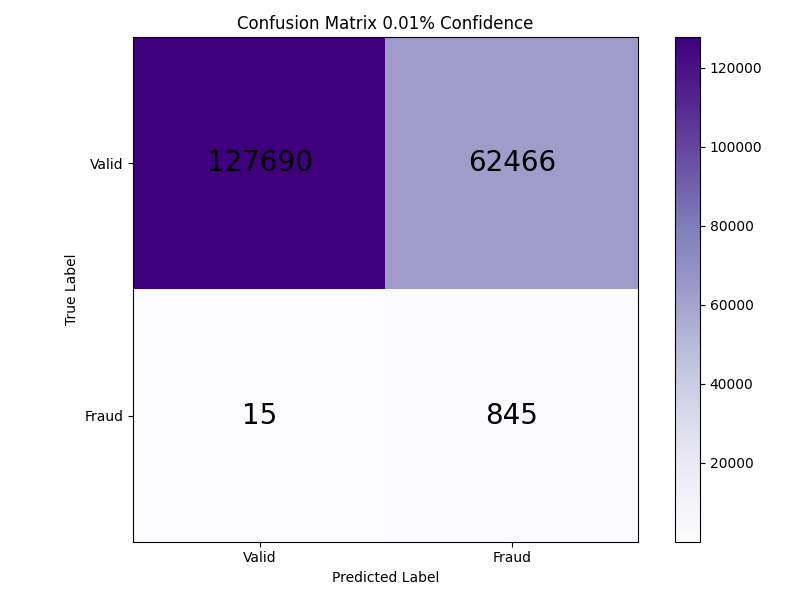

In [40]:
fraud_confusion_matrix(predictions0001,'Purples', 0.0001)
%matplot plt